<a href="https://colab.research.google.com/github/twillixa/Algorithm-in-BI/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install odfpy -q
!git clone https://github.com/twillixa/Algorithm-in-BI.git
%cd Algorithm-in-BI
import pandas as pd
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Cloning into 'Algorithm-in-BI'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 52 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 1.73 MiB | 16.14 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/Algorithm-in-BI


##Loading

In [3]:


clients  = pd.read_excel("RawData/clients.ods",  engine="odf")
comandes = pd.read_excel("RawData/comandes.ods", engine="odf")
commandes_details = pd.read_excel("RawData/commandes details.ods", engine="odf")

clients.to_csv("RawData/clients.csv",   index=False, encoding="utf-8-sig")
comandes.to_csv("RawData/comandes.csv", index=False, encoding="utf-8-sig")

print(f"clients  → {clients.shape}")
print(f"comandes → {comandes.shape}")

clients  → (1537, 5)
comandes → (2039, 11)


##Cleaning

In [4]:
# 1. Drop unnecessary columns
comandes.drop(columns=["NOM", "EMAIL", "DEVISE"], inplace=True, errors="ignore")

# 2a. Parse DATE COMMANDE as datetime
comandes["DATE COMMANDE"] = pd.to_datetime(comandes["DATE COMMANDE"])

# 2b. Standardize ANNEE DE NAISSANCE → extract year as integer
comandes["ANNEE DE NAISSANCE"] = (
    comandes["ANNEE DE NAISSANCE"]
    .astype(str)
    .str.extract(r"(\d{4})")
    .astype("Int64")
)

# 3. Cast CODE POSTAL to string
comandes["CODE POSTAL"] = (
    comandes["CODE POSTAL"]
    .astype(str)
    .str.strip()
    .replace("nan", pd.NA)
)

# 4. Flag & drop duplicate CODE COMMANDE
comandes["IS_DUPLICATE"] = comandes.duplicated(subset="CODE COMMANDE", keep=False)
print(f"Duplicate orders flagged: {comandes['IS_DUPLICATE'].sum()}")
comandes = comandes[comandes["IS_DUPLICATE"] == False].drop(columns=["IS_DUPLICATE"])

# 5. Categorical variable for MODE DE PAIEMENT
comandes["MODE DE PAIEMENT"] = pd.Categorical(comandes["MODE DE PAIEMENT"])
print("Payment categories:", comandes["MODE DE PAIEMENT"].cat.categories.tolist())

# 6. Compute age
comandes["AGE"] = 2026 - comandes["ANNEE DE NAISSANCE"]

print(comandes.dtypes)
display(comandes.head())



# 1. Drop unnecessary columns
clients.drop(columns=["NOM", "EMAIL"], inplace=True, errors="ignore")

# 2. Standardize ANNÉE DE NAISSANCE → extract year as integer
clients["ANNÉE DE NAISSANCE"] = (
    clients["ANNÉE DE NAISSANCE"]
    .astype(str)
    .str.extract(r"(\d{4})")
    .astype("Int64")
)

# 3. Compute age
clients["AGE"] = 2026 - clients["ANNÉE DE NAISSANCE"]

display(clients.head())

Duplicate orders flagged: 0
Payment categories: ['Caisse - Carte de crédit', 'Carte de crédit', 'Gratuit', 'Postcard', 'Twint']
PRENOM                        object
CODE COMMANDE                  int64
DATE COMMANDE         datetime64[ns]
MONTANT                        int64
MODE DE PAIEMENT            category
NB BILLETS                     int64
CODE POSTAL                   object
ANNEE DE NAISSANCE             Int64
AGE                            Int64
dtype: object


,PRENOM,CODE COMMANDE,DATE COMMANDE,MONTANT,MODE DE PAIEMENT,NB BILLETS,CODE POSTAL,ANNEE DE NAISSANCE,AGE
0,fiona,69863303,2025-12-16 13:55:55,142,Carte de crédit,3,<NA>,1972,54
1,Natascha,69865565,2025-12-16 16:19:31,93,Twint,2,1023,1964,62
2,Martine,69866924,2025-12-16 17:28:10,44,Twint,1,1510,1964,62
3,Pierre-Philippe,69866513,2025-12-16 17:32:24,88,Carte de crédit,2,1033,1955,71
4,Sandra,69869702,2025-12-16 19:57:18,49,Twint,1,1022,1976,50


,PRENOM,CODE POSTAL,ANNÉE DE NAISSANCE,AGE
0,Abel,1003,1994,32
1,Adam,1022,1999,27
2,Adam,2740,2003,23
3,Adela,1007,1976,50
4,Adèle,1040,2003,23


In [5]:



# Merge on order number — ticket level
merged = commandes_details.merge(
    comandes,
    left_on="order number",
    right_on="CODE COMMANDE",
    how="left"
)

# Drop duplicate and irrelevant columns
merged.drop(columns=[
    # Duplicates (keeping comandes versions)
    "payment mode", "Customer", "Customer Firstname",
    # Irrelevant
    "order status", "memo", "Barcode", "Barcode Datas", "Type",
    "Seat", "Row", "Block", "Email", "Zone","EMAIL",
    "Customer Lastname","NOM","DEVISE","status",
    "promo","Seller Firstname","Seller Lastname",
    "Customer Language", "comment", "Pass email",
    "Pass Firstname", "Pass Lastname", "Pass Email",
    # Clean up merge key duplicate
    "CODE COMMANDE"
], inplace=True, errors="ignore")

print(f"merged → {merged.shape}")
print(merged.dtypes)
display(merged.head())

merged → (8578, 16)
event name                       object
event date                       object
Booking date                     object
order number                      int64
Amount                            int64
Amount avec promotion             int64
Event date                       object
Tariff                           object
PRENOM                           object
DATE COMMANDE            datetime64[ns]
MONTANT                         float64
MODE DE PAIEMENT               category
NB BILLETS                      float64
CODE POSTAL                      object
ANNEE DE NAISSANCE                Int64
AGE                               Int64
dtype: object


,event name,event date,Booking date,order number,Amount,Amount avec promotion,Event date,Tariff,PRENOM,DATE COMMANDE,MONTANT,MODE DE PAIEMENT,NB BILLETS,CODE POSTAL,ANNEE DE NAISSANCE,AGE
0,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 13:55:55,69863303,49,49,2026-03-06 19:35:43,Tarif plein,fiona,2025-12-16 13:55:55,142.0,Carte de crédit,3.0,<NA>,1972,54
1,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 13:55:55,69863303,49,49,NaN,Tarif plein,fiona,2025-12-16 13:55:55,142.0,Carte de crédit,3.0,<NA>,1972,54
2,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 13:55:55,69863303,44,44,2026-03-06 19:39:38,Tarif réduit,fiona,2025-12-16 13:55:55,142.0,Carte de crédit,3.0,<NA>,1972,54
3,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 16:19:31,69865565,49,49,2026-03-06 19:36:16,Tarif plein,Natascha,2025-12-16 16:19:31,93.0,Twint,2.0,1023,1964,62
4,Another Kind Of Magic – A vocal tribute to Queen,2026-03-06 20:00:00,2025-12-16 16:19:31,69865565,44,44,2026-03-06 19:36:23,Tarif réduit,Natascha,2025-12-16 16:19:31,93.0,Twint,2.0,1023,1964,62


In [6]:
print(merged.isnull().sum())
print(f"\nTotal rows: {len(merged)}")


event name                  0
event date                  0
Booking date                0
order number                0
Amount                      0
Amount avec promotion       0
Event date               4498
Tariff                      0
PRENOM                   3040
DATE COMMANDE            3017
MONTANT                  3017
MODE DE PAIEMENT         3017
NB BILLETS               3017
CODE POSTAL              3284
ANNEE DE NAISSANCE       3166
AGE                      3166
dtype: int64

Total rows: 8578


##Graph

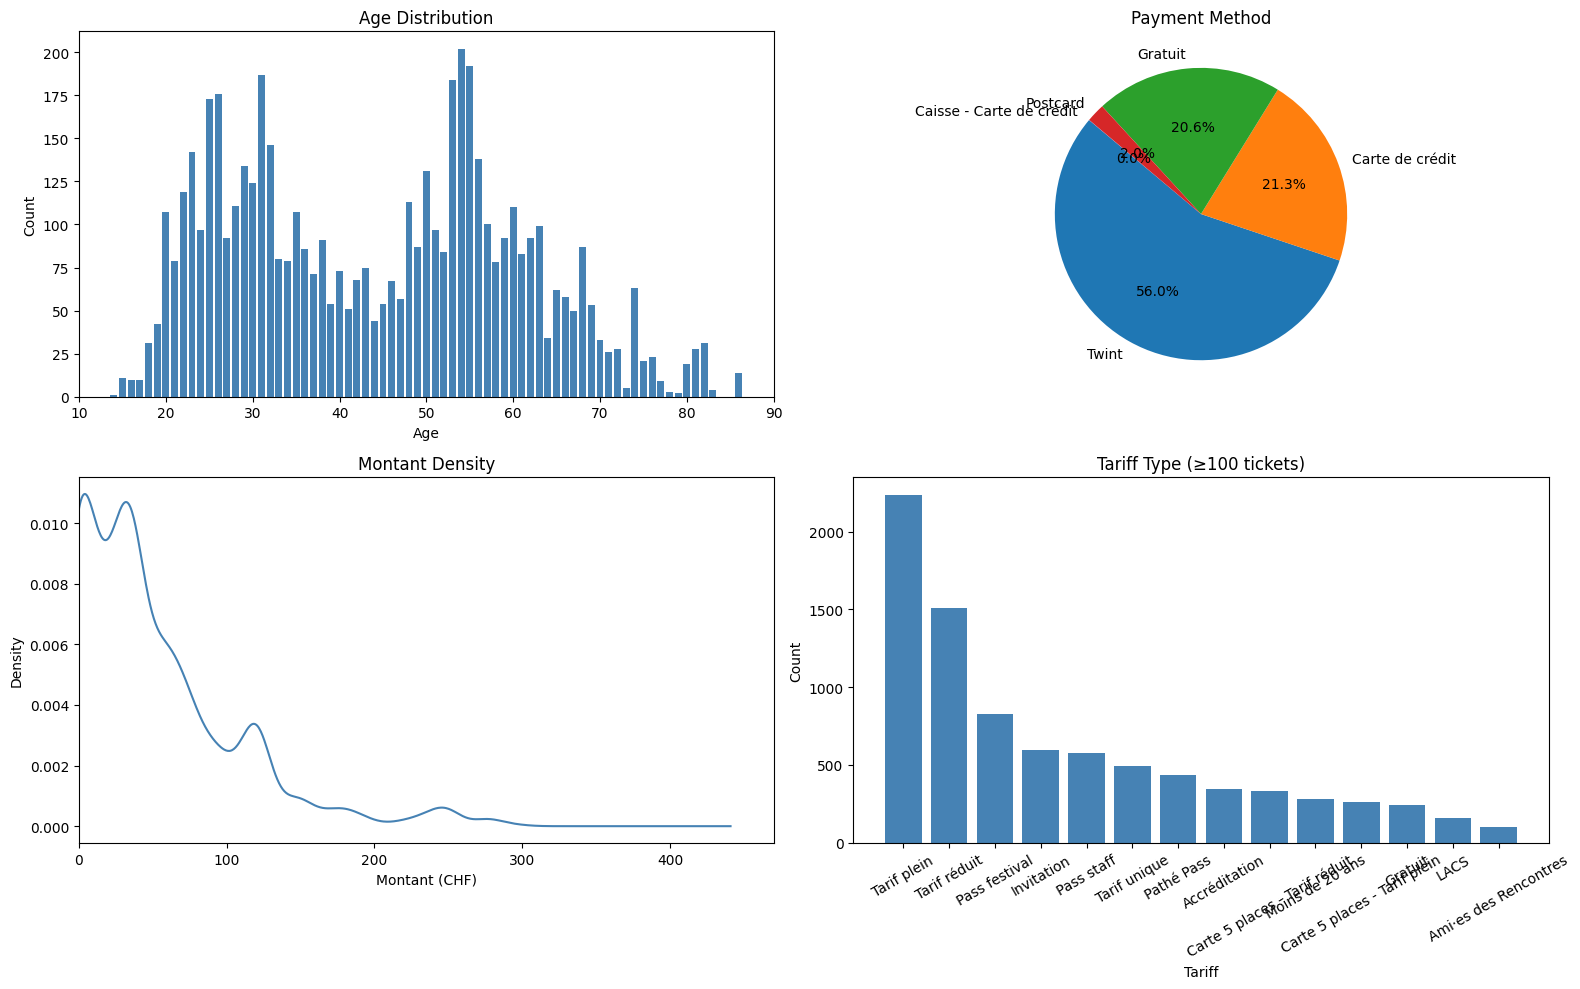

In [7]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Age distribution — cap to valid range
age_data = merged["AGE"].dropna()
age_data = age_data[(age_data >= 0) & (age_data <= 120)]
age_counts = age_data.value_counts().sort_index()
axes[0, 0].bar(age_counts.index, age_counts.values, color="steelblue")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# 2. Pie chart — Payment method
payment_counts = merged["MODE DE PAIEMENT"].dropna().value_counts()
axes[0, 1].pie(payment_counts.values, labels=payment_counts.index, autopct="%1.1f%%", startangle=140)
axes[0, 1].set_title("Payment Method")

# 3. Density plot — Montant, starting at 0
montant_data = merged["MONTANT"].dropna()
montant_data = montant_data[montant_data >= 0]
montant_data.plot.kde(ax=axes[1, 0], color="steelblue")
axes[1, 0].set_xlim(left=0)
axes[1, 0].set_title("Montant Density")
axes[1, 0].set_xlabel("Montant (CHF)")

# 4. Tariff type — exclude categories with less than 100 tickets
tariff_counts = merged["Tariff"].dropna().value_counts()
tariff_counts = tariff_counts[tariff_counts >= 100]
axes[1, 1].bar(tariff_counts.index, tariff_counts.values, color="steelblue")
axes[1, 1].set_title("Tariff Type (≥100 tickets)")
axes[1, 1].set_xlabel("Tariff")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [8]:
!pip install folium -q
import pandas as pd
import folium
from folium.plugins import HeatMap

# Swiss postal codes with lat/lng from geonames (filtered to CH)
url = "https://raw.githubusercontent.com/datumorphism/geonames-postal-codes-geocoordinates/master/dataset/postal_codes_and_coordinates.csv"
plz = pd.read_csv(url)
plz_ch = plz[plz["country_code"] == "CH"][["postal_code", "latitude", "longitude"]].drop_duplicates("postal_code")
plz_ch["postal_code"] = plz_ch["postal_code"].astype(str)

# Aggregate ticket counts per postal code
postal_counts = (
    merged["CODE POSTAL"].dropna()
    .astype(str).str.strip()
    .value_counts()
    .reset_index()
)
postal_counts.columns = ["postal_code", "count"]

# Merge with coordinates
geo = postal_counts.merge(plz_ch, on="postal_code", how="left").dropna(subset=["latitude", "longitude"])
print(f"Matched {len(geo)} / {len(postal_counts)} postal codes")

# Build heatmap
heat_data = [[row["latitude"], row["longitude"], row["count"]] for _, row in geo.iterrows()]

m = folium.Map(location=[46.8, 8.2], zoom_start=8, tiles="CartoDB positron")
HeatMap(heat_data, radius=20, blur=25, min_opacity=0.4).add_to(m)

m.save("density_map.html")
m

Matched 245 / 274 postal codes


/tmp/ipykernel_15827/163675309.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plz = pd.read_csv(url)


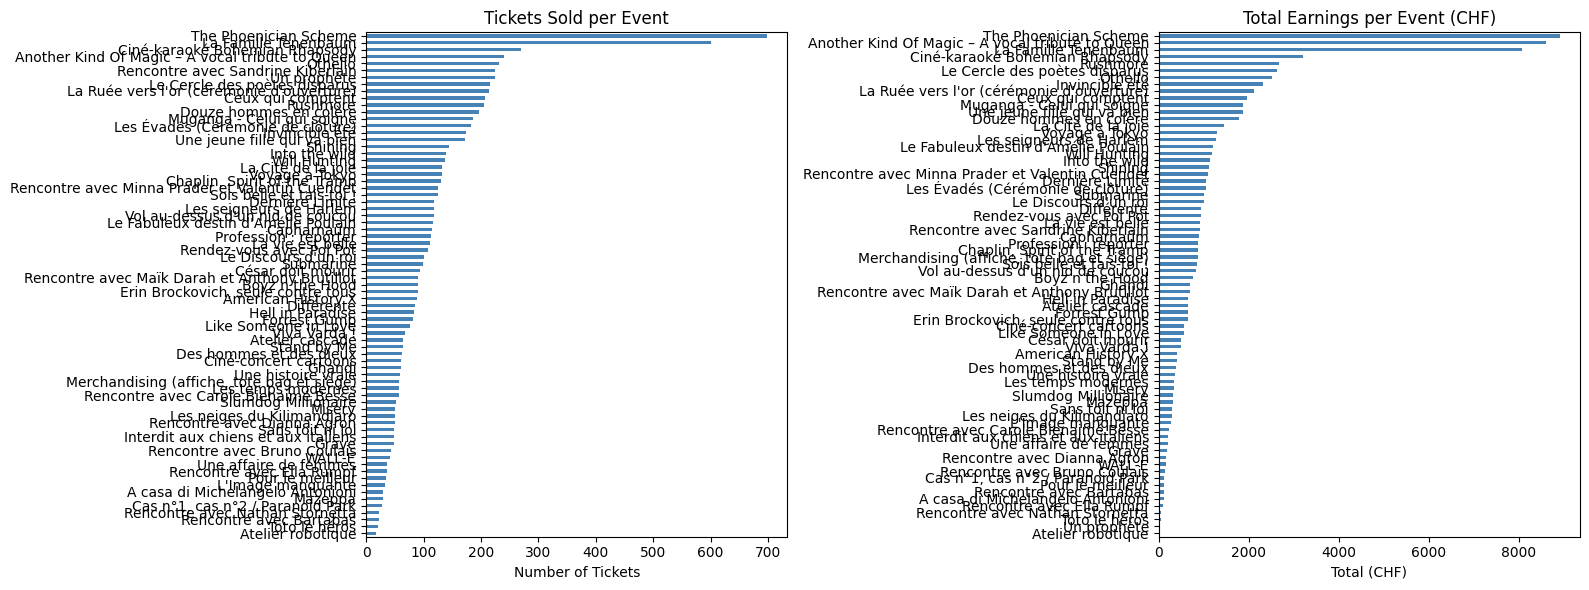

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tickets sold per event
tickets_per_event = (
    merged.groupby("event name")["order number"]
    .count()
    .sort_values(ascending=True)
)
tickets_per_event.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Tickets Sold per Event")
axes[0].set_xlabel("Number of Tickets")
axes[0].set_ylabel("")

# 2. Aggregate earnings per event (prix_final = Amount avec promotion)
earnings_per_event = (
    merged.groupby("event name")["Amount avec promotion"]
    .sum()
    .sort_values(ascending=True)
)
earnings_per_event.plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Total Earnings per Event (CHF)")
axes[1].set_xlabel("Total (CHF)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Showing the different event names

In [10]:
event_names_list = list(merged['event name'].unique())
print(event_names_list)

['Another Kind Of Magic – A vocal tribute to Queen', 'Cas n°1, cas n°2 / Paranoid Park', 'Rencontre avec Sandrine Kiberlain', 'The Phoenician Scheme', 'Grave', 'Une histoire vraie', "Vol au-dessus d'un nid de coucou", 'Shining', 'La Famille Tenenbaum', 'Une affaire de femmes', 'Will Hunting', 'Une jeune fille qui va bien', 'Othello', "La Ruée vers l'or (cérémonie d'ouverture)", 'Rushmore', 'Les seigneurs de Harlem', 'Chaplin, Spirit of the Tramp', 'Submarine', 'César doit mourir', 'Rencontre avec Bruno Coulais', "Le Discours d'un roi", 'Rencontre avec Minna Prader et Valentin Cuendet', 'Ceux qui comptent', 'Muganga - Celui qui soigne', 'Hell in Paradise', 'Rencontre avec Bartabas', 'Ciné-karaoké Bohemian Rhapsody', 'Voyage à Tokyo', 'Les Évadés (Cérémonie de clôture)', 'La vie est belle', 'A casa di Michelangelo Antonioni', 'WALL-E', 'Atelier cascade', 'Rencontre avec Ella Rumpf', 'Rencontre avec Dianna Agron', 'Sois belle et tais-toi !', 'Erin Brockovich, seule contre tous', 'Le Cercl

Scan the event names list to sort them based on their genre

In [11]:
# 1. The hardcoded dictionary with your categories
genres_dict = {
    "Another Kind Of Magic – A vocal tribute to Queen": "Concert / Spectacle",
    "Cas n°1, cas n°2 / Paranoid Park": "Film - Drame",
    "Rencontre avec Sandrine Kiberlain": "Rencontre / Conférence",
    "The Phoenician Scheme": "Film - Comédie",
    "Grave": "Film - Horreur",
    "Une histoire vraie": "Film - Drame",
    "Vol au-dessus d'un nid de coucou": "Film - Drame",
    "Shining": "Film - Horreur / Thriller",
    "La Famille Tenenbaum": "Film - Comédie dramatique",
    "Une affaire de femmes": "Film - Drame",
    "Will Hunting": "Film - Drame",
    "Une jeune fille qui va bien": "Film - Drame",
    "Othello": "Film - Drame",
    "La Ruée vers l'or (cérémonie d'ouverture)": "Cérémonie / Événement",
    "Rushmore": "Film - Comédie",
    "Les seigneurs de Harlem": "Film - Action",
    "Chaplin, Spirit of the Tramp": "Film - Documentaire",
    "Submarine": "Film - Comédie dramatique",
    "César doit mourir": "Film - Drame",
    "Rencontre avec Bruno Coulais": "Rencontre / Conférence",
    "Le Discours d'un roi": "Film - Biopic",
    "Rencontre avec Minna Prader et Valentin Cuendet": "Rencontre / Conférence",
    "Ceux qui comptent": "Film - Documentaire",
    "Muganga - Celui qui soigne": "Film - Documentaire",
    "Hell in Paradise": "Film - Drame",
    "Rencontre avec Bartabas": "Rencontre / Conférence",
    "Ciné-karaoké Bohemian Rhapsody": "Concert / Spectacle",
    "Voyage à Tokyo": "Film - Drame",
    "Les Évadés (Cérémonie de clôture)": "Cérémonie / Événement",
    "La vie est belle": "Film - Comédie dramatique",
    "A casa di Michelangelo Antonioni": "Film - Documentaire",
    "WALL-E": "Film - Animation",
    "Atelier cascade": "Atelier / Activité",
    "Rencontre avec Ella Rumpf": "Rencontre / Conférence",
    "Rencontre avec Dianna Agron": "Rencontre / Conférence",
    "Sois belle et tais-toi !": "Film - Documentaire",
    "Erin Brockovich, seule contre tous": "Film - Biopic",
    "Le Cercle des poètes disparus": "Film - Drame",
    "Le Fabuleux destin d'Amélie Poulain": "Film - Comédie romantique",
    "Like Someone in Love": "Film - Drame",
    "Slumdog Millionaire": "Film - Drame",
    "Into the wild": "Film - Aventure",
    "Dernière Limite": "Film - Action",
    "Sans toit ni loi": "Film - Drame",
    "Boyz n the Hood": "Film - Drame",
    "Capharnaüm": "Film - Drame",
    "Viva Varda !": "Film - Documentaire",
    "Différente": "Film - Drame",
    "Les neiges du Kilimandjaro": "Film - Drame",
    "Rencontre avec Maïk Darah et Anthony Brutillot": "Rencontre / Conférence",
    "Rendez-vous avec Pol Pot": "Film - Drame",
    "Rencontre avec Nathan Stornetta": "Rencontre / Conférence",
    "Rencontre avec Carole Bienaimé Besse": "Rencontre / Conférence",
    "American History X": "Film - Drame",
    "Douze hommes en colère": "Film - Drame",
    "Les temps modernes": "Film - Classique / Comédie",
    "La Cité de la joie": "Film - Drame",
    "Toto le héros": "Film - Comédie dramatique",
    "Forrest Gump": "Film - Comédie dramatique",
    "L'Image manquante": "Film - Documentaire",
    "Ciné-concert cartoons": "Concert / Spectacle",
    "Invincible été": "Film - Documentaire",
    "Interdit aux chiens et aux italiens": "Film - Animation",
    "Stand by Me": "Film - Aventure",
    "Pour le meilleur": "Film - Comédie",
    "Misery": "Film - Thriller",
    "Un prophète": "Film - Thriller / Drame",
    "Atelier robotique": "Atelier / Activité",
    "Mazeppa": "Film - Drame",
    "Des hommes et des dieux": "Film - Drame",
    "Profession : reporter": "Film - Drame",
    "Ghandi": "Film - Biopic",
    "Merchandising (affiche, tote bag et siège)": "Boutique / Produit dérivé"
}

print("\n--- Integration into Pandas ---")

# 2. Create the new 'genre' column
# We use map() to link the existing column to our dictionary
merged['genre'] = merged['event name'].map(genres_dict)

# 3. Replace missing values (Optional but recommended)
# If an event name is not exactly matching the dictionary, Pandas will insert a blank (NaN).
# We replace these blanks with "Unclassified" to keep the data clean.
merged['genre'] = merged['genre'].fillna("Unclassified")

# 4. Verify the result
print("Preview of your updated DataFrame:")
print(merged[['event name', 'genre']].head(10))


--- Integration into Pandas ---
Preview of your updated DataFrame:
                                         event name                genre
0  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
1  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
2  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
3  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
4  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
5  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
6  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
7  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
8  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle
9  Another Kind Of Magic – A vocal tribute to Queen  Concert / Spectacle


Showing the relation between film/event categories and client age

/tmp/ipykernel_15827/1029832432.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[0].boxplot(data_to_plot, labels=sorted_genres, vert=False, patch_artist=True)


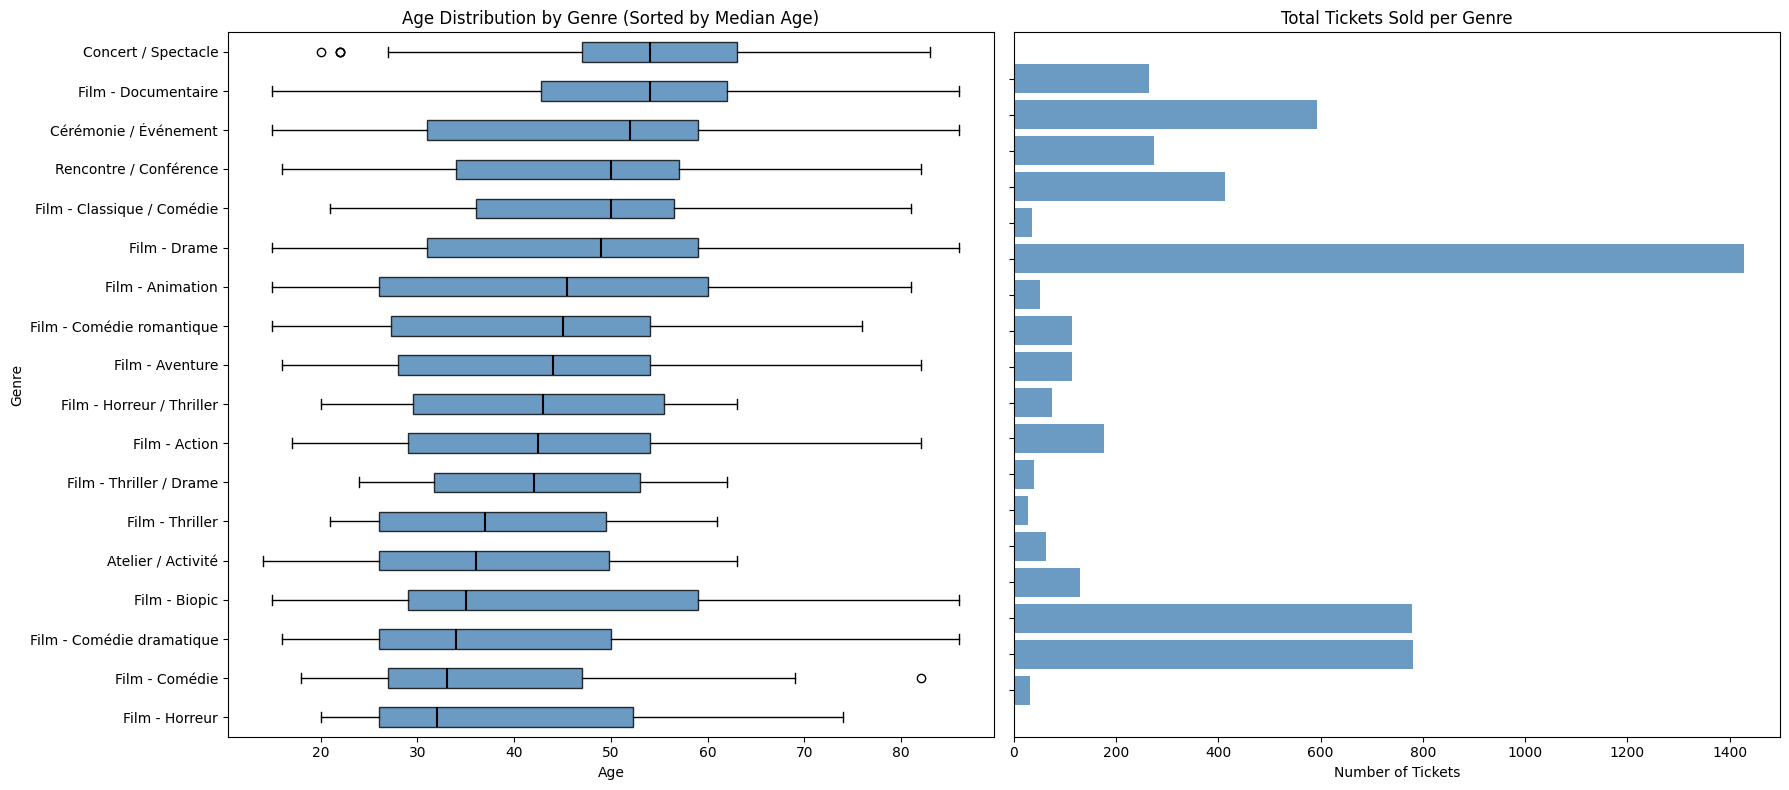

In [12]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns for a wide display
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 0. Data Preparation
# Drop missing values for Age and Genre, and cap age to valid range
valid_data = merged.dropna(subset=['AGE', 'genre'])
valid_data = valid_data[(valid_data['AGE'] >= 0) & (valid_data['AGE'] <= 120)]

# Calculate median age per genre to sort the charts logically
median_ages = valid_data.groupby('genre')['AGE'].median().sort_values()
sorted_genres = median_ages.index

# 1. Horizontal Boxplot — Age distribution per genre
# We group the age data into a list of arrays based on the sorted genres
data_to_plot = [valid_data[valid_data['genre'] == g]['AGE'] for g in sorted_genres]

# Plot the boxplot (vert=False makes it horizontal to easily read long genre names)
bplot = axes[0].boxplot(data_to_plot, labels=sorted_genres, vert=False, patch_artist=True)

# Apply styling to match your previous charts
for box in bplot['boxes']:
    box.set_facecolor("steelblue")
    box.set_alpha(0.8)
for median in bplot['medians']:
    median.set_color("black") # Highlight the median line
    median.set_linewidth(1.5)

axes[0].set_title("Age Distribution by Genre (Sorted by Median Age)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Genre")

# 2. Horizontal Bar chart — Volume of tickets per genre
# We count tickets and reindex using 'sorted_genres' to keep the exact same order as the boxplot
genre_counts = valid_data['genre'].value_counts().reindex(sorted_genres)

axes[1].barh(genre_counts.index, genre_counts.values, color="steelblue", alpha=0.8)
axes[1].set_title("Total Tickets Sold per Genre")
axes[1].set_xlabel("Number of Tickets")

# Remove y-axis labels on the second plot to avoid clutter, since they align with the first plot
axes[1].set_yticklabels([])

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()

Fetching geographic coordinates...


/tmp/ipykernel_15827/2749209084.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plz = pd.read_csv(url)


Data ready: 5148 valid rows found with exact coordinates.


/tmp/ipykernel_15827/2749209084.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot_geo = axes[0].boxplot(data_to_plot_geo, labels=cluster_labels, patch_artist=True)


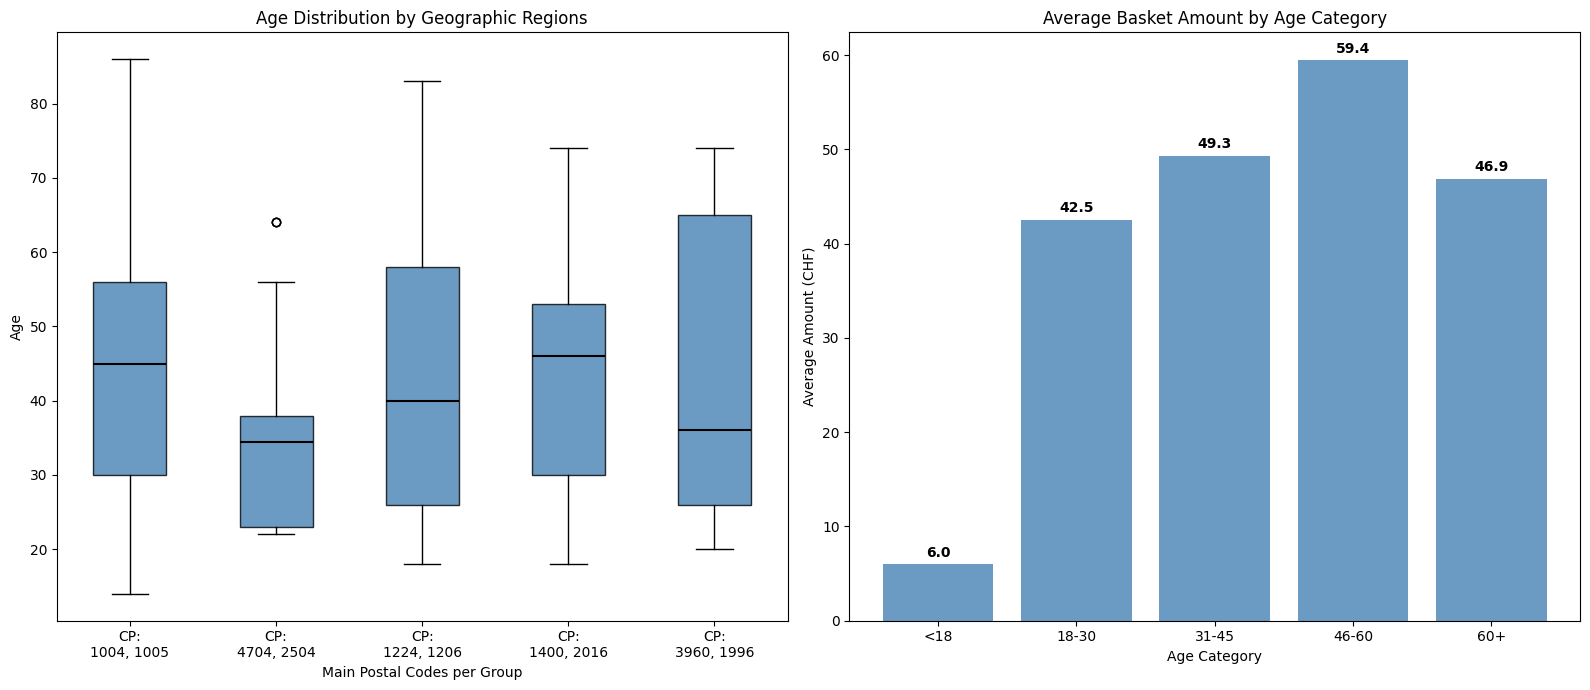

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# --- PART 0: Fetch and prepare geographical data ---
print("Fetching geographic coordinates...")

url = "https://raw.githubusercontent.com/datumorphism/geonames-postal-codes-geocoordinates/master/dataset/postal_codes_and_coordinates.csv"
plz = pd.read_csv(url)
plz_ch = plz[plz["country_code"] == "CH"][["postal_code", "latitude", "longitude"]].drop_duplicates("postal_code")
plz_ch["postal_code"] = plz_ch["postal_code"].astype(str)

merged["CODE POSTAL"] = merged["CODE POSTAL"].astype(str).str.strip()
merged_with_geo = merged.merge(plz_ch, left_on="CODE POSTAL", right_on="postal_code", how="left")

# --- PART 1 & 2: Data Preparation ---
valid_data = merged_with_geo.dropna(subset=['AGE', 'MONTANT', 'latitude', 'longitude']).copy()
valid_data = valid_data[(valid_data['AGE'] >= 0) & (valid_data['AGE'] <= 120)]

print(f"Data ready: {len(valid_data)} valid rows found with exact coordinates.")

# --- PART 3: Geographic Clustering (5 Groups) ---
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
valid_data['Geo_Cluster'] = kmeans.fit_predict(valid_data[['latitude', 'longitude']])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: Age Distribution by Geographic Clusters ---

# DYNAMIC LABELS: Extract the top 2 postal codes for each cluster to name the X-axis
cluster_labels = []
for i in range(5):
    # Get the 2 most frequent postal codes in this specific cluster
    top_postal_codes = valid_data[valid_data['Geo_Cluster'] == i]['CODE POSTAL'].value_counts().head(2).index.tolist()
    # Create a string label like "CP:\n1000, 1004"
    label = f"CP:\n{', '.join(top_postal_codes)}"
    cluster_labels.append(label)

data_to_plot_geo = [valid_data[valid_data['Geo_Cluster'] == i]['AGE'] for i in range(5)]

bplot_geo = axes[0].boxplot(data_to_plot_geo, labels=cluster_labels, patch_artist=True)

for box in bplot_geo['boxes']:
    box.set_facecolor("steelblue")
    box.set_alpha(0.8)
for median in bplot_geo['medians']:
    median.set_color("black")
    median.set_linewidth(1.5)

axes[0].set_title("Age Distribution by Geographic Regions")
axes[0].set_ylabel("Age")
axes[0].set_xlabel("Main Postal Codes per Group")

# --- PLOT 2: Average Basket Amount by Age Category ---
age_bins = [0, 18, 30, 45, 60, 120]
age_labels = ['<18', '18-30', '31-45', '46-60', '60+']

valid_data['Age_Category'] = pd.cut(valid_data['AGE'], bins=age_bins, labels=age_labels, right=False)
avg_montant_per_age = valid_data.groupby('Age_Category', observed=True)['MONTANT'].mean()

axes[1].bar(avg_montant_per_age.index.astype(str), avg_montant_per_age.values, color="steelblue", alpha=0.8)

axes[1].set_title("Average Basket Amount by Age Category")
axes[1].set_xlabel("Age Category")
axes[1].set_ylabel("Average Amount (CHF)")

for i, value in enumerate(avg_montant_per_age.values):
    if not np.isnan(value):
        axes[1].text(i, value + 0.5, f"{value:.1f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

##Clustering

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import numpy as np

# Load Swiss postal code coordinates
plz_url = "https://raw.githubusercontent.com/datumorphism/geonames-postal-codes-geocoordinates/master/dataset/postal_codes_and_coordinates.csv"
plz = pd.read_csv(plz_url)
plz_ch = plz[plz["country_code"] == "CH"][["postal_code", "latitude", "longitude"]].drop_duplicates("postal_code")
plz_ch["postal_code"] = plz_ch["postal_code"].astype(str)

# Aggregate to order level, collecting all genres attended per order
cluster_df = (
    merged.groupby("order number").agg(
        AGE=("AGE", "first"),
        MONTANT=("MONTANT", "first"),
        CODE_POSTAL=("CODE POSTAL", "first"),
    ).reset_index()
)

# One-hot encode genres per order
genre_dummies = (
    merged.groupby("order number")["genre"]
    .apply(lambda x: x.unique().tolist())
    .reset_index()
)
genre_dummies = genre_dummies.join(
    genre_dummies["genre"]
    .apply(lambda genres: pd.Series({g: 1 for g in genres}))
    .fillna(0)
).drop(columns=["genre"])

cluster_df = cluster_df.merge(genre_dummies, on="order number", how="left")

# Merge coordinates
cluster_df["CODE_POSTAL"] = cluster_df["CODE_POSTAL"].astype(str).str.strip()
cluster_df = cluster_df.merge(plz_ch, left_on="CODE_POSTAL", right_on="postal_code", how="left")

# Filter valid ages
cluster_df = cluster_df[(cluster_df["AGE"] >= 0) & (cluster_df["AGE"] <= 120)]

genre_cols = [c for c in cluster_df.columns if c not in
              ["order number", "AGE", "MONTANT", "CODE_POSTAL",
               "postal_code", "latitude", "longitude", "cluster"]]

print(f"Clustering dataset: {cluster_df.shape}")
print(f"Genres: {genre_cols}")

/tmp/ipykernel_15827/814222068.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plz = pd.read_csv(plz_url)


Clustering dataset: (1960, 26)
Genres: ['Concert / Spectacle', 'Film - Drame', 'Rencontre / Conférence', 'Film - Comédie', 'Film - Horreur', 'Film - Horreur / Thriller', 'Film - Comédie dramatique', 'Cérémonie / Événement', 'Film - Action', 'Film - Documentaire', 'Film - Biopic', 'Film - Animation', 'Atelier / Activité', 'Film - Comédie romantique', 'Film - Aventure', 'Film - Classique / Comédie', 'Film - Thriller', 'Film - Thriller / Drame', 'Boutique / Produit dérivé']


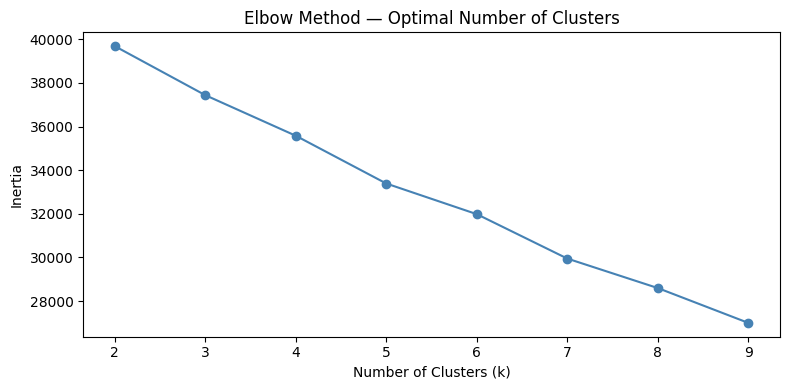

In [23]:
features = ["AGE", "MONTANT", "latitude", "longitude"] + genre_cols
X = cluster_df[features].copy()

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker="o", color="steelblue")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

           AGE  MONTANT
cluster                
0        47.76    27.32
1        54.29    72.29
2        33.93    31.58
3         41.9    61.77
4        41.77     3.65


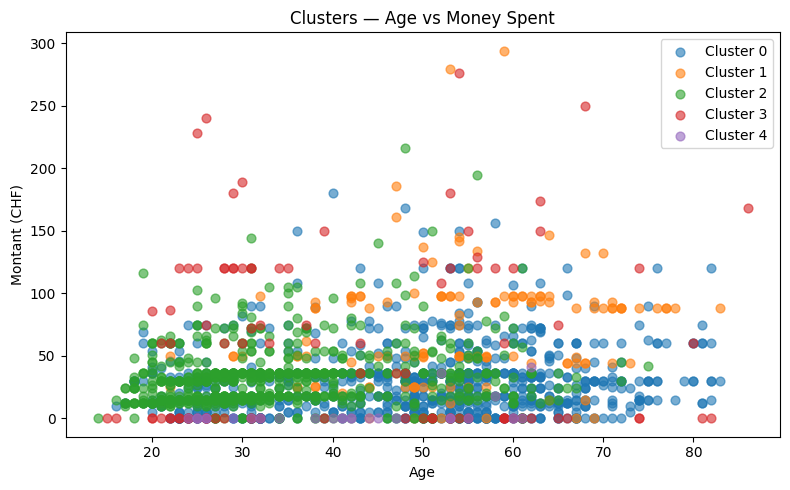

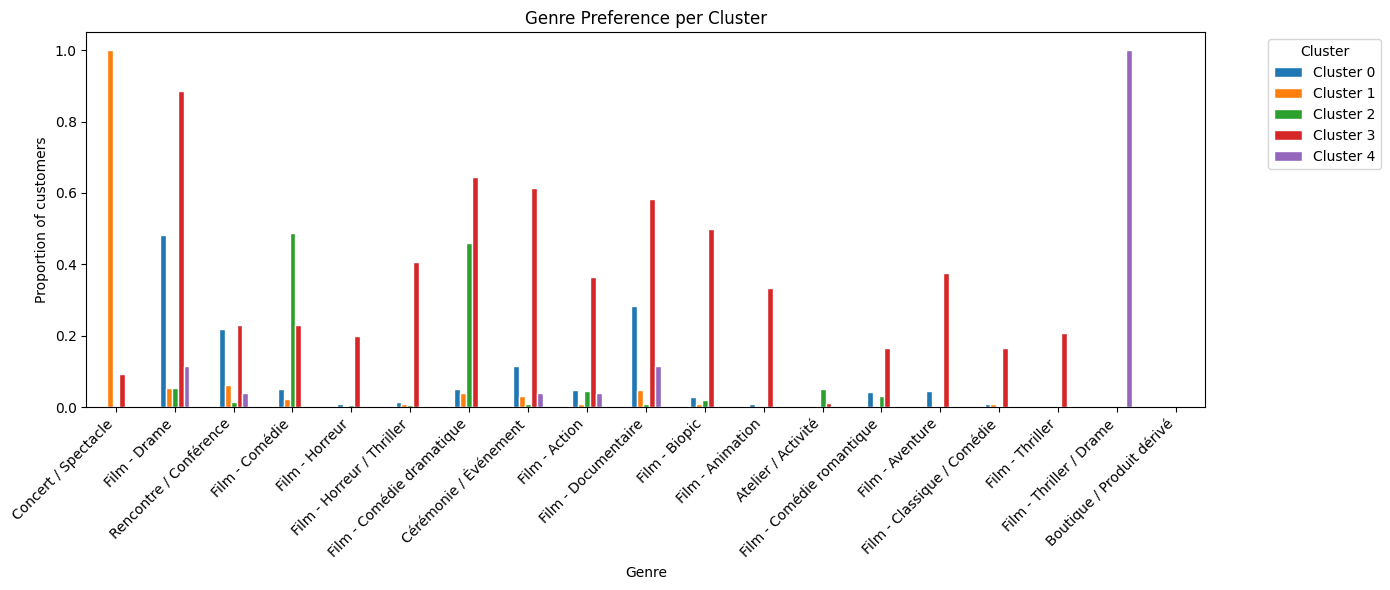

In [27]:
import matplotlib.cm as cm

K = 5  #  adjust after elbow plot

km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df["cluster"] = km.fit_predict(X_scaled)

# Define consistent colors for all graphs
colors = [plt.cm.tab10(i) for i in range(K)]
cluster_labels = [f"Cluster {c}" for c in range(K)]

# Cluster profiles
print(cluster_df.groupby("cluster")[["AGE", "MONTANT"]].mean().round(2))

# Scatter — Age vs Montant
plt.figure(figsize=(8, 5))
for c in range(K):
    subset = cluster_df[cluster_df["cluster"] == c]
    plt.scatter(subset["AGE"], subset["MONTANT"], label=cluster_labels[c],
                color=colors[c], alpha=0.6, s=40)
plt.title("Clusters — Age vs Money Spent")
plt.xlabel("Age")
plt.ylabel("Montant (CHF)")
plt.legend()
plt.tight_layout()
plt.show()

# Genre preference per cluster
genre_profile = cluster_df.groupby("cluster")[genre_cols].mean()

genre_profile.T.plot(kind="bar", figsize=(14, 6), color=colors, edgecolor="white")
plt.title("Genre Preference per Cluster")
plt.xlabel("Genre")
plt.ylabel("Proportion of customers")
plt.xticks(rotation=45, ha="right")
plt.legend(cluster_labels, title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

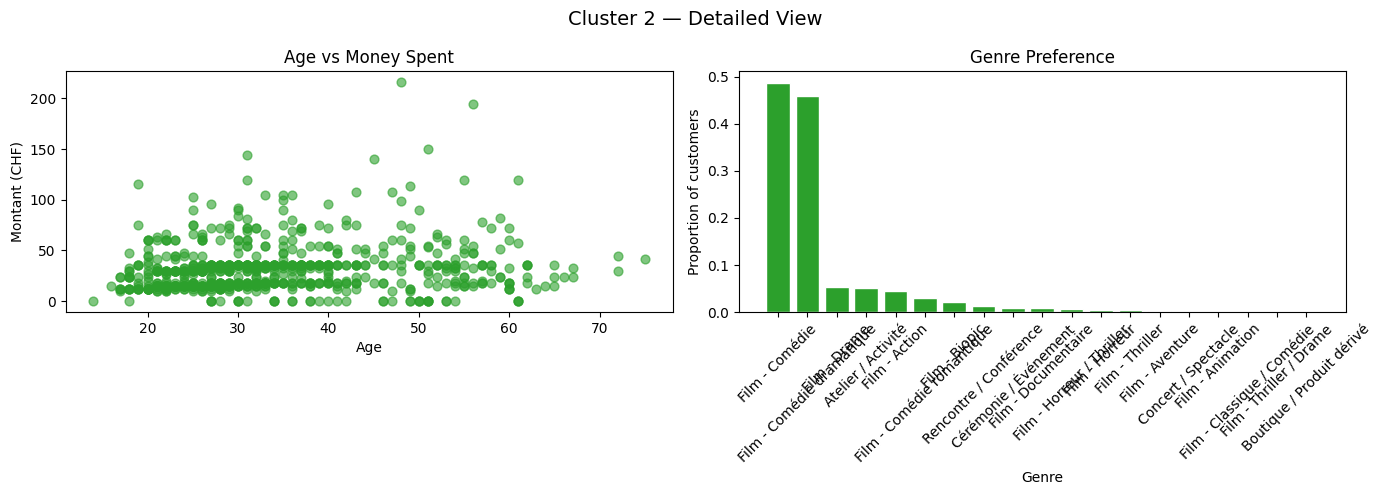

Cluster 2 — 753 orders
         AGE  MONTANT
count  753.0   753.00
mean   33.93    31.58
std    11.85    23.87
min     14.0     0.00
25%     25.0    15.00
50%     31.0    30.00
75%     40.0    36.00
max     75.0   216.00


In [29]:
# Change this to the cluster you want to inspect
CLUSTER = 2


subset = cluster_df[cluster_df["cluster"] == CLUSTER]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Cluster {CLUSTER} — Detailed View", fontsize=14)

# Age vs Montant
axes[0].scatter(subset["AGE"], subset["MONTANT"], color=colors[CLUSTER], alpha=0.6, s=40)
axes[0].set_title("Age vs Money Spent")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Montant (CHF)")

# Genre preference
genre_means = subset[genre_cols].mean().sort_values(ascending=False)
axes[1].bar(genre_means.index, genre_means.values, color=colors[CLUSTER], edgecolor="white")
axes[1].set_title("Genre Preference")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Proportion of customers")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Cluster {CLUSTER} — {len(subset)} orders")
print(subset[["AGE", "MONTANT"]].describe().round(2))

In [31]:
# Summary table per cluster
summary = cluster_df.groupby("cluster").agg(
    count=("AGE", "count"),
    age_mean=("AGE", "mean"),
    age_median=("AGE", "median"),
    montant_mean=("MONTANT", "mean"),
    montant_median=("MONTANT", "median"),
).round(2)

# Add top 2 genres per cluster
def top_genres(row_mean, n=2):
    # Ensure we only sort and select from genre columns
    return ", ".join(row_mean[genre_cols].sort_values(ascending=False).head(n).index.tolist())

# Calculate the mean of only the genre columns for each cluster
genre_cluster_means = cluster_df.groupby("cluster")[genre_cols].mean()

# Apply the top_genres function to the calculated means
summary["top_genres"] = genre_cluster_means.apply(top_genres, axis=1)

summary.columns = ["Count", "Age Mean", "Age Median", "Montant Mean", "Montant Median", "Top Genres"]
display(summary)

,Count,Age Mean,Age Median,Montant Mean,Montant Median,Top Genres
cluster,,,,,,
0,956,47.76,50.0,27.32,18.0,"Film - Drame, Film - Documentaire"
1,129,54.29,54.0,72.29,88.0,"Concert / Spectacle, Rencontre / Conférence"
2,753,33.93,31.0,31.58,30.0,"Film - Comédie, Film - Comédie dramatique"
3,96,41.9,36.0,61.77,48.0,"Film - Drame, Film - Comédie dramatique"
4,26,41.77,41.5,3.65,0.0,"Film - Thriller / Drame, Film - Documentaire"
